# World Cup 2026 Predictor - Live Validation

This notebook validates model predictions against already-played World Cup 2026 matches.

In [7]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from src.config import PROCESSED_DIR, RAW_DIR
from src.models.live_validation import validate_against_live

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Model

In [8]:
models_dir = PROCESSED_DIR / 'models'
model = joblib.load(models_dir / 'best_model.joblib')
feature_cols = joblib.load(models_dir / 'feature_columns.joblib')
print(f'Loaded model with {len(feature_cols)} features')

Loaded model with 80 features


## 2. Run Live Validation

In [9]:
results = validate_against_live(model, feature_cols)
if results:
    print(f'\nAccuracy (argmax): {results["accuracy_argmax"]:.4f}')
    print(f'Accuracy (draw threshold): {results["accuracy_threshold"]:.4f}')
    print(f'Log Loss: {results["log_loss"]:.4f}')
    print(f'Matches: {results["total_matches"]}')
    print(f'Correct (argmax): {results["correct_argmax"]}/{results["total_matches"]}')
    print(f'Correct (threshold): {results["correct_threshold"]}/{results["total_matches"]}')

2026-06-16 09:02:35,702 [INFO] worldcup: Validating model against live WC 2026 results...
2026-06-16 09:02:35,705 [INFO] worldcup: Found 16 played WC 2026 matches to validate against
2026-06-16 09:02:36,205 [INFO] worldcup: Live validation results:
2026-06-16 09:02:36,205 [INFO] worldcup:   Matches: 16
2026-06-16 09:02:36,206 [INFO] worldcup:   Accuracy (argmax): 0.3750
2026-06-16 09:02:36,206 [INFO] worldcup:   Accuracy (draw threshold 0.85): 0.3750
2026-06-16 09:02:36,206 [INFO] worldcup:   Log Loss: 1.0969
2026-06-16 09:02:36,208 [INFO] worldcup:   Saved to /Users/sithea/Documents/code/worldcup/data/processed/live_validation_report.csv
2026-06-16 09:02:36,208 [INFO] worldcup:   ✓ Mexico 2-0 South Africa | Pred: home_win (argmax: home_win) | Actual: home_win | H:0.73 D:0.18 A:0.09 | D/max: 0.24
2026-06-16 09:02:36,208 [INFO] worldcup:   ✓ South Korea 2-1 Czech Republic | Pred: home_win (argmax: home_win) | Actual: home_win | H:0.38 D:0.29 A:0.32 | D/max: 0.77
2026-06-16 09:02:36,208 


Accuracy (argmax): 0.3750
Accuracy (draw threshold): 0.3750
Log Loss: 1.0969
Matches: 16
Correct (argmax): 6/16
Correct (threshold): 6/16


## 3. Per-Match Analysis

In [10]:
if results and not results['results'].empty:
    df = results['results']
    print('Per-match predictions vs actual results:')
    print(df.to_string(index=False))

Per-match predictions vs actual results:
    home_team          away_team  home_score  away_score actual_outcome predicted_outcome predicted_argmax  prob_home_win  prob_draw  prob_away_win  draw_ratio  correct
       Mexico       South Africa           2           0       home_win          home_win         home_win       0.729119   0.177600       0.093281    0.243581     True
  South Korea     Czech Republic           2           1       home_win          home_win         home_win       0.383877   0.293679       0.322443    0.765034     True
       Canada Bosnia-Herzegovina           1           1           draw          home_win         home_win       0.584660   0.272552       0.142788    0.466172    False
United States           Paraguay           4           1       home_win          home_win         home_win       0.397080   0.262253       0.340667    0.660453     True
        Qatar        Switzerland           1           1           draw          away_win         away_win       0

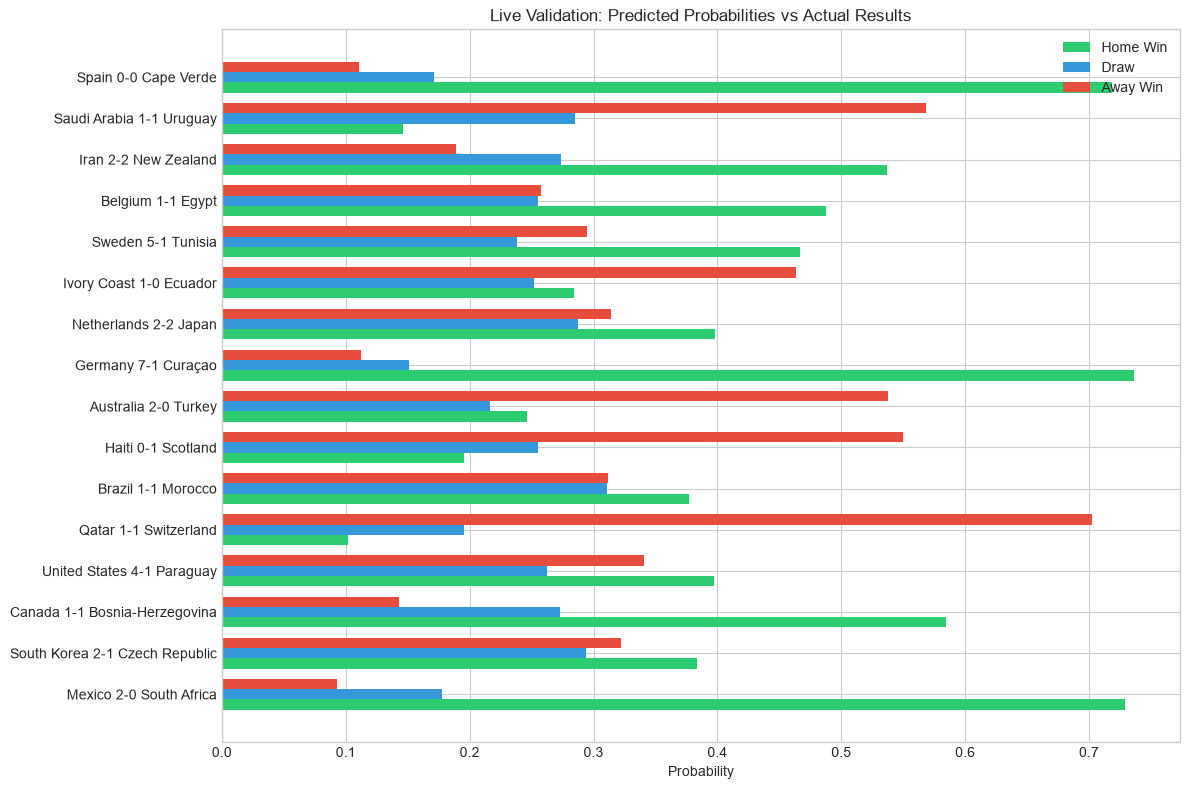

In [11]:
if results and not results['results'].empty:
    df = results['results']

    fig, ax = plt.subplots(figsize=(12, max(6, len(df) * 0.5)))

    y_pos = range(len(df))
    bar_width = 0.25

    ax.barh([y - bar_width for y in y_pos], df['prob_home_win'], bar_width, label='Home Win', color='#2ecc71')
    ax.barh(y_pos, df['prob_draw'], bar_width, label='Draw', color='#3498db')
    ax.barh([y + bar_width for y in y_pos], df['prob_away_win'], bar_width, label='Away Win', color='#e74c3c')

    labels = [f"{r['home_team']} {r['home_score']}-{r['away_score']} {r['away_team']}" for _, r in df.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Probability')
    ax.set_title('Live Validation: Predicted Probabilities vs Actual Results')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Confusion Analysis

In [12]:
if results and not results['results'].empty:
    df = results['results']

    correct = df['correct'].sum()
    total = len(df)
    incorrect = total - correct

    print(f'Correct predictions: {correct}/{total} ({correct/total*100:.1f}%)')
    print(f'Incorrect predictions: {incorrect}/{total} ({incorrect/total*100:.1f}%)')

    if incorrect > 0:
        wrong = df[~df['correct']]
        print(f'\nIncorrect predictions:')
        for _, r in wrong.iterrows():
            print(f'  {r["home_team"]} vs {r["away_team"]}: predicted {r["predicted_outcome"]}, actual {r["actual_outcome"]}')

Correct predictions: 6/16 (37.5%)
Incorrect predictions: 10/16 (62.5%)

Incorrect predictions:
  Canada vs Bosnia-Herzegovina: predicted home_win, actual draw
  Qatar vs Switzerland: predicted away_win, actual draw
  Brazil vs Morocco: predicted home_win, actual draw
  Australia vs Turkey: predicted away_win, actual home_win
  Netherlands vs Japan: predicted home_win, actual draw
  Ivory Coast vs Ecuador: predicted away_win, actual home_win
  Belgium vs Egypt: predicted home_win, actual draw
  Iran vs New Zealand: predicted home_win, actual draw
  Saudi Arabia vs Uruguay: predicted away_win, actual draw
  Spain vs Cape Verde: predicted home_win, actual draw
